# ECG Dataset Quality Report

Full-dataset scan for missing/flat leads, recording length anomalies, amplitude outliers, and class balance across CODE-15%, SaMi-Trop, and PTB-XL.

**Run order:** execute cells top-to-bottom.  
**Re-scan:** set `FORCE_RESCAN = True` to ignore cached CSVs and re-run the full scan.  
**PTB-XL:** set `PTBXL_SAMPLE = None` to scan all 21,799 records (~30 min); default is 500.

In [1]:
import os
import re
import sys
import warnings
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import wfdb

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

# run from project root regardless of where Jupyter was launched
if Path(os.getcwd()).name == "notebooks":
    os.chdir("..")
sys.path.insert(0, "src")

warnings.filterwarnings("ignore", category=UserWarning)

# ── config ────────────────────────────────────────────────────────────────────
FORCE_RESCAN        = False   # True to re-run full data scans (ignores CSV cache)
FLAT_STD_THRESHOLD  = 0.05    # raw signal std in mV; below this → flat/missing lead
PTBXL_SAMPLE        = None    # PTB-XL records to scan (None = all 21,799, ~30 min)

REPORTS_DIR = Path("reports")
FIGURES_DIR = REPORTS_DIR / "figures"
REPORTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

LEAD_NAMES = ["I", "II", "III", "AVR", "AVL", "AVF", "V1", "V2", "V3", "V4", "V5", "V6"]
DATASET_COLORS = {"CODE-15%": "#4C72B0", "SaMi-Trop": "#DD8452", "PTB-XL": "#55A868"}

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

print("Working directory:", os.getcwd())
print("Reports will be saved to:", REPORTS_DIR.resolve())

Working directory: /Users/lsandler/Documents/GitHub/chagas-ecg-explainability
Reports will be saved to: /Users/lsandler/Documents/GitHub/chagas-ecg-explainability/reports


## Scan helpers

`analyze_record` runs on a single raw `[T, 12]` signal and returns per-lead quality metrics.  
The three `scan_*` functions run it over an entire dataset, caching results to CSV.

In [2]:
def analyze_record(signal_tc: np.ndarray, fs: float) -> dict:
    """
    Quality metrics for a single raw ECG record.

    signal_tc : [T, 12] array, any float dtype, leads in standard order
    fs        : sampling frequency in Hz

    Returns a flat dict of scalar metrics.
    """
    sig = signal_tc.astype(np.float64)

    # actual signal length: last row where any lead is nonzero
    any_nonzero = np.any(sig != 0, axis=1)
    actual_len  = int(np.where(any_nonzero)[0][-1]) + 1 if any_nonzero.any() else 0
    real        = sig[:actual_len] if actual_len > 0 else sig

    d = {
        "actual_length_samples": actual_len,
        "actual_length_sec"    : round(actual_len / fs, 2),
        "has_nan"              : bool(np.isnan(sig).any()),
        "has_inf"              : bool(np.isinf(sig).any()),
        "amplitude_p99_mv"     : float(np.percentile(np.abs(real), 99)) if actual_len else 0.0,
        "amplitude_max_mv"     : float(np.abs(real).max())              if actual_len else 0.0,
    }

    n_flat = 0
    for i, lead in enumerate(LEAD_NAMES):
        std = float(real[:, i].std()) if actual_len else 0.0
        d[f"{lead}_std_mv"] = std
        d[f"{lead}_flat"]   = std < FLAT_STD_THRESHOLD
        if std < FLAT_STD_THRESHOLD:
            n_flat += 1

    d["n_flat_leads"] = n_flat
    return d


def scan_code15() -> pd.DataFrame:
    cache = REPORTS_DIR / "code15_scan.csv"
    if cache.exists() and not FORCE_RESCAN:
        print(f"  loaded cache: {cache}")
        return pd.read_csv(cache)

    hdf5_path  = Path("data/code15/exams_part0.hdf5")
    labels_csv = Path("data/code15/code15_chagas_labels.csv")
    if not hdf5_path.exists():
        print(f"  SKIP: {hdf5_path} not found")
        return pd.DataFrame()

    labels = pd.read_csv(labels_csv).set_index("exam_id")["chagas"]

    records, BATCH = [], 500
    with h5py.File(hdf5_path, "r") as f:
        exam_ids = f["exam_id"][:]
        total    = f["tracings"].shape[0]
        for start in tqdm(range(0, total, BATCH), desc="CODE-15%"):
            batch    = f["tracings"][start : start + BATCH]   # [B, 4096, 12]
            batch_ids = exam_ids[start : start + BATCH]
            for sig, eid in zip(batch, batch_ids):
                d = analyze_record(sig, fs=400.0)
                d["exam_id"] = int(eid)
                d["chagas"]  = int(labels.get(int(eid), -1))  # -1 = unlabeled
                d["is_padded"] = d["actual_length_samples"] < 4000
                records.append(d)

    df = pd.DataFrame(records)
    df.to_csv(cache, index=False)
    print(f"  saved {len(df):,} records → {cache}")
    return df


def scan_samitrop() -> pd.DataFrame:
    cache = REPORTS_DIR / "samitrop_scan.csv"
    if cache.exists() and not FORCE_RESCAN:
        print(f"  loaded cache: {cache}")
        return pd.read_csv(cache)

    hdf5_path = Path("data/samitrop/exams.hdf5")
    if not hdf5_path.exists():
        print(f"  SKIP: {hdf5_path} not found")
        return pd.DataFrame()

    records, BATCH = [], 200
    with h5py.File(hdf5_path, "r") as f:
        total = f["tracings"].shape[0]
        for start in tqdm(range(0, total, BATCH), desc="SaMi-Trop"):
            batch = f["tracings"][start : start + BATCH]
            for i, sig in enumerate(batch):
                d = analyze_record(sig, fs=400.0)
                d["record_idx"] = start + i
                d["chagas"]     = 1   # all Chagas positive by design
                d["is_padded"]  = d["actual_length_samples"] < 4000
                records.append(d)

    df = pd.DataFrame(records)
    df.to_csv(cache, index=False)
    print(f"  saved {len(df):,} records → {cache}")
    return df


def scan_ptbxl(n_sample=None) -> pd.DataFrame:
    tag   = str(n_sample) if n_sample else "all"
    cache = REPORTS_DIR / f"ptbxl_scan_n{tag}.csv"
    if cache.exists() and not FORCE_RESCAN:
        print(f"  loaded cache: {cache}")
        return pd.read_csv(cache)

    records_file = Path("data/ptbxl/RECORDS")
    if not records_file.exists():
        print(f"  SKIP: {records_file} not found")
        return pd.DataFrame()

    text     = records_file.read_text()
    hr_paths = re.findall(r"records\d+/\d+/\d+_hr", text)
    if n_sample:
        hr_paths = hr_paths[:n_sample]

    records = []
    for rel in tqdm(hr_paths, desc=f"PTB-XL (n={len(hr_paths)})"):
        full = Path("data/ptbxl") / rel
        if not full.with_suffix(".hea").exists():
            continue
        rec = wfdb.rdrecord(str(full))
        d   = analyze_record(rec.p_signal, fs=rec.fs)
        d["path"]      = rel
        d["chagas"]    = 0   # Chagas-negative cohort by design
        d["is_padded"] = d["actual_length_samples"] < int(rec.fs * 10)  # < 10s
        records.append(d)

    df = pd.DataFrame(records)
    df.to_csv(cache, index=False)
    print(f"  saved {len(df):,} records → {cache}")
    return df

## Run scans

First run takes a few minutes per dataset (CODE-15%: ~2 min, SaMi-Trop: <30 s, PTB-XL n=500: ~1 min).  
Subsequent runs load from cache instantly.

In [3]:
print("CODE-15%")
df_c15 = scan_code15()

print("SaMi-Trop")
df_st = scan_samitrop()

print("PTB-XL")
df_ptb = scan_ptbxl(PTBXL_SAMPLE)

datasets = [
    ("CODE-15%",  df_c15,  400),
    ("SaMi-Trop", df_st,   400),
    ("PTB-XL",    df_ptb,  500),
]

for name, df, _ in datasets:
    if not df.empty:
        print(f"  {name}: {len(df):,} records")

CODE-15%
  loaded cache: reports/code15_scan.csv
SaMi-Trop
  loaded cache: reports/samitrop_scan.csv
PTB-XL


PTB-XL (n=21799):   0%|          | 0/21799 [00:00<?, ?it/s]

  saved 21,799 records → reports/ptbxl_scan_nall.csv
  CODE-15%: 20,001 records
  SaMi-Trop: 1,631 records
  PTB-XL: 21,799 records


---
## 1. Flat / Missing Lead Analysis

A lead is flagged as flat when its raw signal standard deviation is below `FLAT_STD_THRESHOLD` (default 0.05 mV).  
This catches dead electrodes, lead-off artefacts, and corrupted channels.

The grouped bar chart shows what fraction of records have a flat reading on each of the 12 leads,  
broken down by dataset. Leads that are systematically flat across a dataset indicate a structural  
data issue rather than random electrode drop-out.

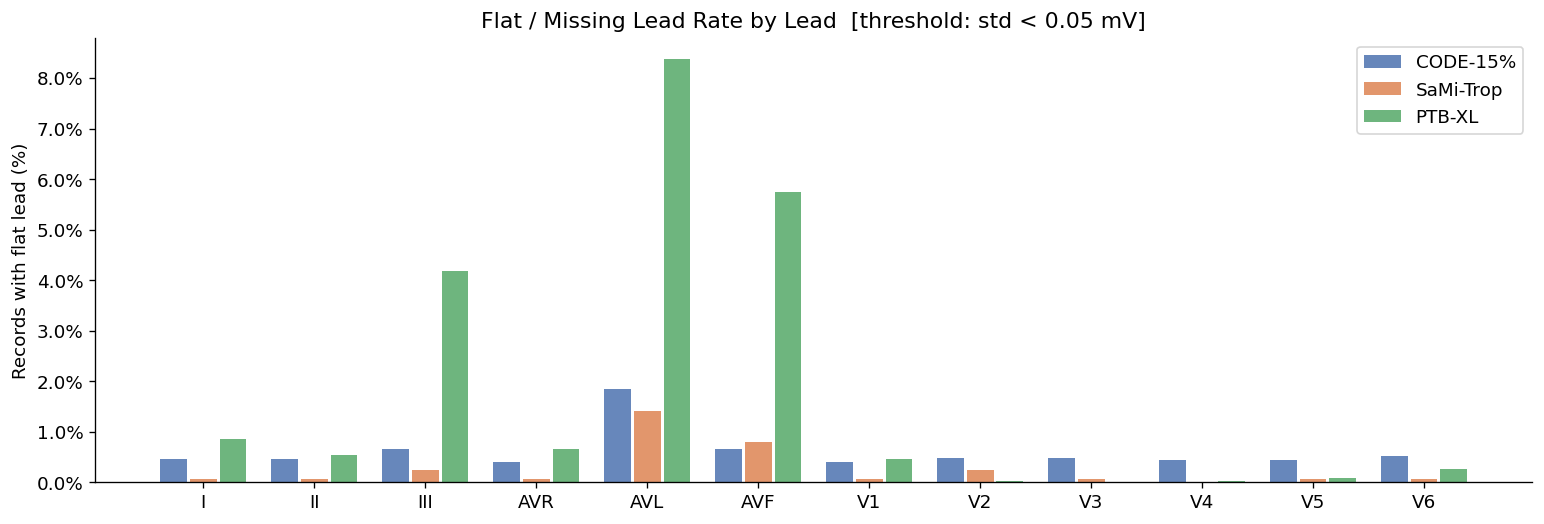

,total,I,II,III,AVR,AVL,AVF,V1,V2,V3,V4,V5,V6
dataset,,,,,,,,,,,,,
CODE-15%,20001,93 (0.5%),94 (0.5%),132 (0.7%),82 (0.4%),370 (1.8%),131 (0.7%),79 (0.4%),97 (0.5%),97 (0.5%),90 (0.4%),87 (0.4%),106 (0.5%)
SaMi-Trop,1631,1 (0.1%),1 (0.1%),4 (0.2%),1 (0.1%),23 (1.4%),13 (0.8%),1 (0.1%),4 (0.2%),1 (0.1%),0 (0.0%),1 (0.1%),1 (0.1%)
PTB-XL,21799,188 (0.9%),116 (0.5%),910 (4.2%),145 (0.7%),1827 (8.4%),1254 (5.8%),100 (0.5%),4 (0.0%),3 (0.0%),4 (0.0%),17 (0.1%),57 (0.3%)


In [4]:
fig, ax = plt.subplots(figsize=(13, 4.5))

n_ds    = sum(1 for _, df, _ in datasets if not df.empty)
width   = 0.8 / n_ds
x       = np.arange(len(LEAD_NAMES))
offsets = np.linspace(-(n_ds - 1) / 2, (n_ds - 1) / 2, n_ds) * width

for offset, (name, df, _) in zip(offsets, datasets):
    if df.empty:
        continue
    rates = [df[f"{lead}_flat"].mean() * 100 for lead in LEAD_NAMES]
    bars  = ax.bar(x + offset, rates, width * 0.9, label=name,
                   color=DATASET_COLORS[name], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(LEAD_NAMES)
ax.set_ylabel("Records with flat lead (%)")
ax.set_title(f"Flat / Missing Lead Rate by Lead  [threshold: std < {FLAT_STD_THRESHOLD} mV]")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
ax.axhline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "flat_lead_rates.png", bbox_inches="tight")
plt.show()

# per-lead flat counts table
flat_rows = []
for name, df, _ in datasets:
    if df.empty:
        continue
    row = {"dataset": name, "total": len(df)}
    for lead in LEAD_NAMES:
        n = int(df[f"{lead}_flat"].sum())
        row[lead] = f"{n} ({n/len(df):.1%})"
    flat_rows.append(row)

pd.DataFrame(flat_rows).set_index("dataset")

### Records with multiple flat leads

A single flat lead might be random electrode drop; multiple flat leads in the same record  
suggests a more severe acquisition problem (cable failure, wrong lead configuration, etc.).

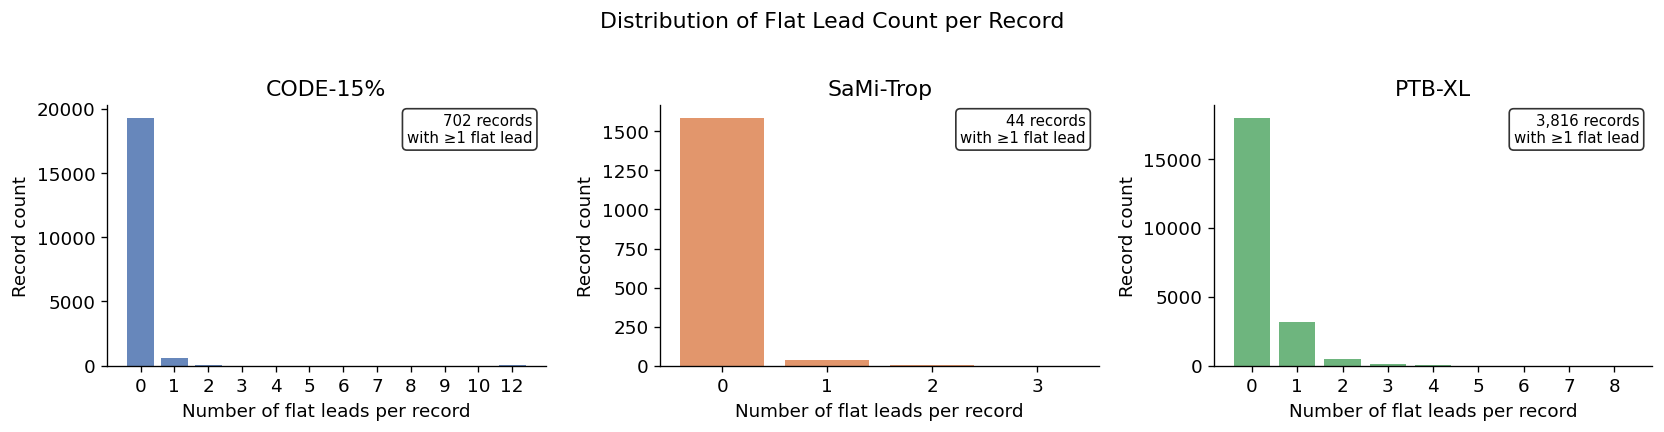

In [5]:
fig, axes = plt.subplots(1, len(datasets), figsize=(14, 3.5), sharey=False)

for ax, (name, df, _) in zip(axes, datasets):
    if df.empty:
        ax.set_title(f"{name}\n(no data)")
        continue
    counts = df["n_flat_leads"].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color=DATASET_COLORS[name], alpha=0.85)
    ax.set_xlabel("Number of flat leads per record")
    ax.set_ylabel("Record count")
    ax.set_title(name)
    total_affected = int((df["n_flat_leads"] > 0).sum())
    ax.text(0.97, 0.97, f"{total_affected:,} records\nwith ≥1 flat lead",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.suptitle("Distribution of Flat Lead Count per Record", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "flat_leads_per_record.png", bbox_inches="tight")
plt.show()

---
## 2. Recording Length Distribution

CODE-15% and SaMi-Trop store recordings as either 10 s (4000 samples at 400 Hz) or 7 s (2800 samples),  
zero-padded to 4096 in the HDF5 file. The preprocessing pipeline strips trailing zeros before filtering,  
so the model only sees real cardiac signal.

This chart shows the distribution of *actual* (unpadded) recording length in seconds.

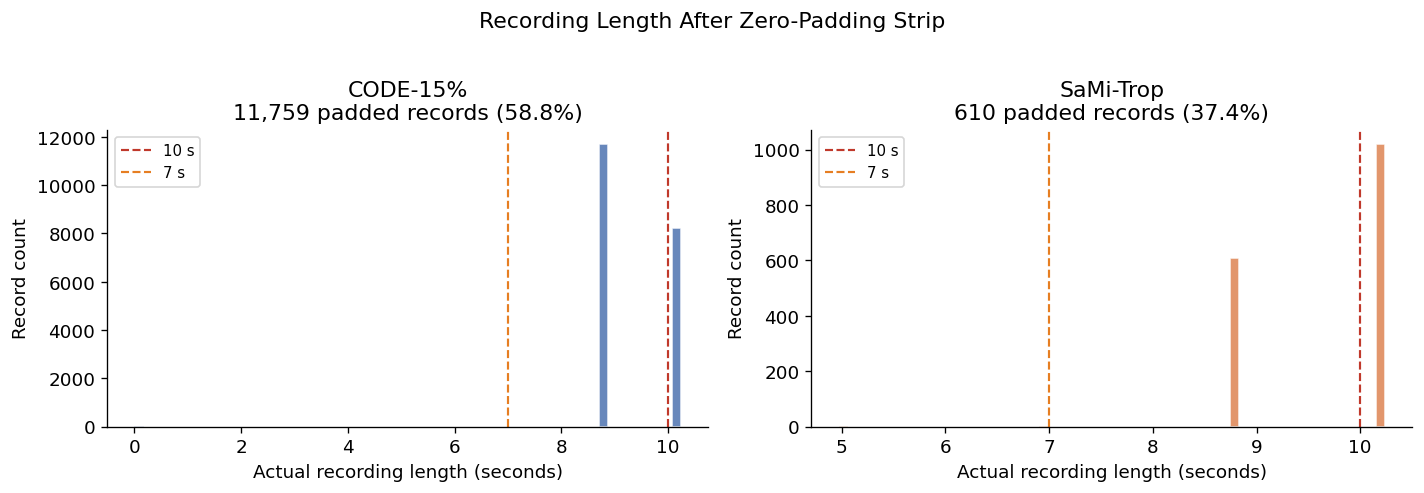

In [6]:
hdf5_datasets = [(n, df, fs) for n, df, fs in datasets if n in ("CODE-15%", "SaMi-Trop")]
fig, axes = plt.subplots(1, len(hdf5_datasets), figsize=(12, 4))

for ax, (name, df, fs) in zip(axes, hdf5_datasets):
    if df.empty:
        ax.set_title(f"{name}\n(no data)")
        continue
    sec = df["actual_length_sec"]
    ax.hist(sec, bins=60, color=DATASET_COLORS[name], edgecolor="white", alpha=0.85)
    for ref, label, color in [(10.0, "10 s", "#c0392b"), (7.0, "7 s", "#e67e22")]:
        ax.axvline(ref, color=color, linestyle="--", linewidth=1.3, label=label)
    n_padded = int(df["is_padded"].sum())
    ax.set_xlabel("Actual recording length (seconds)")
    ax.set_ylabel("Record count")
    ax.set_title(f"{name}\n{n_padded:,} padded records ({n_padded/len(df):.1%})")
    ax.legend(fontsize=9)

plt.suptitle("Recording Length After Zero-Padding Strip", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "recording_lengths.png", bbox_inches="tight")
plt.show()

---
## 3. Amplitude Distribution

Raw ECG amplitudes should be in the millivolt range (0.1–5 mV typical).  
The box plots show the distribution of per-lead signal standard deviation across all records.  
Leads with unusually high std suggest movement artefact or wrong units;  
leads clustering near zero confirm the flat-lead picture from Section 1.

/var/folders/7p/kxk_bdxn0bj_kqdktdlkjg900000gp/T/ipykernel_25389/1597732041.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp   = ax.boxplot(
/var/folders/7p/kxk_bdxn0bj_kqdktdlkjg900000gp/T/ipykernel_25389/1597732041.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp   = ax.boxplot(
/var/folders/7p/kxk_bdxn0bj_kqdktdlkjg900000gp/T/ipykernel_25389/1597732041.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp   = ax.boxplot(


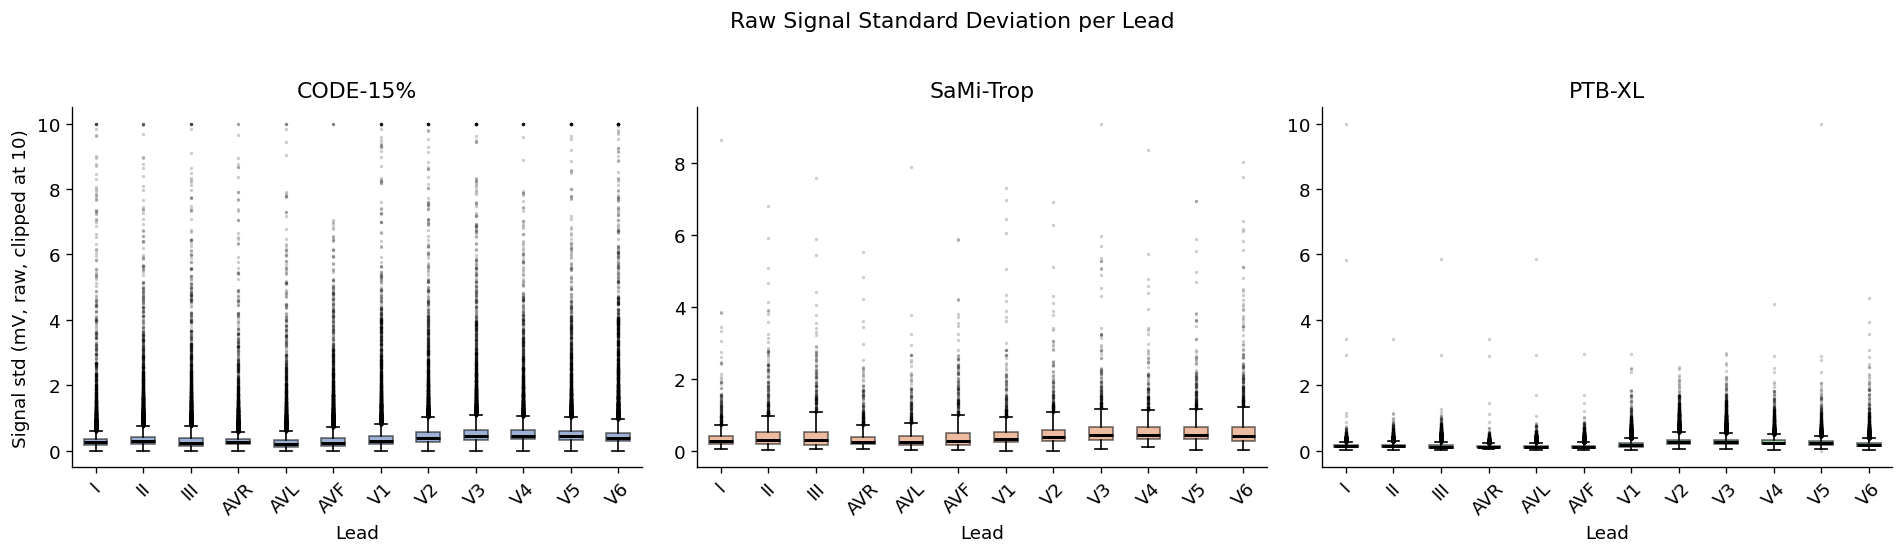

Records with max amplitude > 5 mV (clipped by preprocessing):
  CODE-15%: 7,696 / 20,001 (38.5%)
  SaMi-Trop: 658 / 1,631 (40.3%)
  PTB-XL: 364 / 21,799 (1.7%)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, df, _) in zip(axes, datasets):
    if df.empty:
        ax.set_title(f"{name}\n(no data)")
        ax.set_visible(False)
        continue
    data = [df[f"{lead}_std_mv"].clip(upper=10).values for lead in LEAD_NAMES]
    bp   = ax.boxplot(
        data,
        labels=LEAD_NAMES,
        patch_artist=True,
        boxprops=dict(facecolor=DATASET_COLORS[name], alpha=0.55),
        medianprops=dict(color="black", linewidth=1.8),
        flierprops=dict(marker=".", markersize=2, alpha=0.2),
        whiskerprops=dict(linewidth=1),
        capprops=dict(linewidth=1),
    )
    ax.set_xlabel("Lead")
    ax.set_xticklabels(LEAD_NAMES, rotation=45)
    ax.set_title(name)

axes[0].set_ylabel("Signal std (mV, raw, clipped at 10)")
plt.suptitle("Raw Signal Standard Deviation per Lead", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "amplitude_by_lead.png", bbox_inches="tight")
plt.show()

# amplitude outliers: records where any lead exceeds 5 mV (clipping threshold in preprocessing)
print("Records with max amplitude > 5 mV (clipped by preprocessing):")
for name, df, _ in datasets:
    if df.empty:
        continue
    n = int((df["amplitude_max_mv"] > 5.0).sum())
    print(f"  {name}: {n:,} / {len(df):,} ({n/len(df):.1%})")

---
## 4. Class Balance — CODE-15%

Chagas disease prevalence in CODE-15% is ~2%, creating a severe class imbalance.  
The right panel shows how this imbalance looks in the 90/10 train/val split used by `Code15Dataset`.

Train pos_weight (neg/pos ratio): 48.2


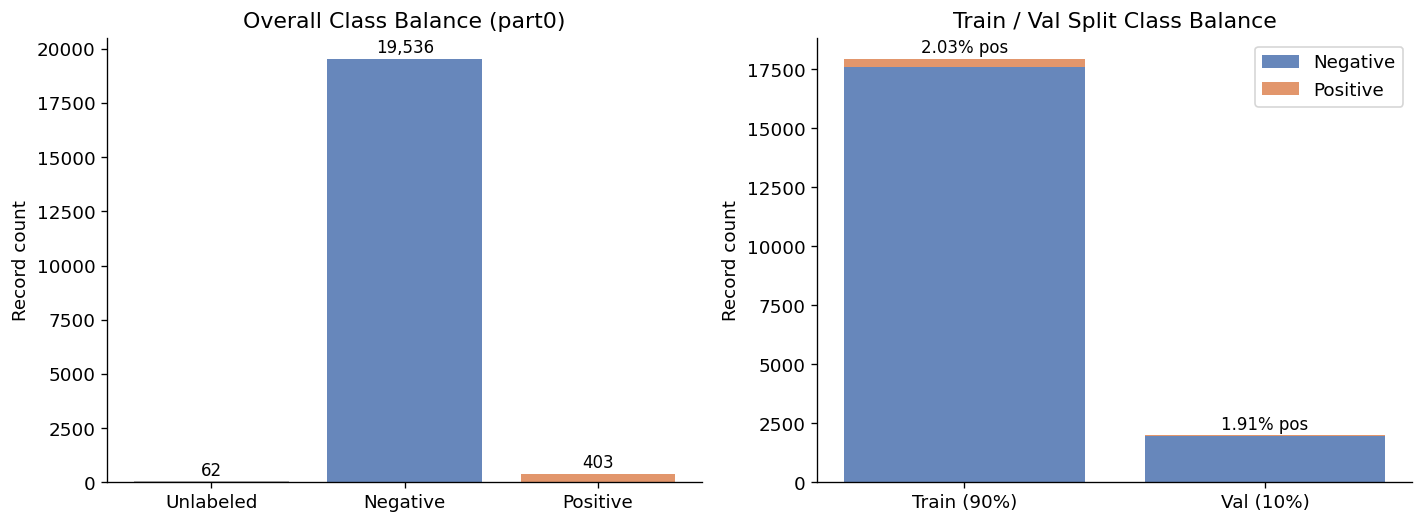

In [8]:
if df_c15.empty:
    print("CODE-15% data not available")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    # ── overall balance ──────────────────────────────────────
    ax = axes[0]
    counts = df_c15["chagas"].value_counts().sort_index()
    label_map = {-1: "Unlabeled", 0: "Negative", 1: "Positive"}
    bar_colors = {-1: "#aaaaaa", 0: "#4C72B0", 1: "#DD8452"}
    for k, v in counts.items():
        ax.bar(label_map.get(k, str(k)), v, color=bar_colors.get(k, "grey"), alpha=0.85)
        ax.text(list(counts.index).index(k), v + 80, f"{v:,}",
                ha="center", va="bottom", fontsize=10)
    ax.set_ylabel("Record count")
    ax.set_title("Overall Class Balance (part0)")

    # ── train / val split ────────────────────────────────────
    ax2 = axes[1]
    labeled  = df_c15[df_c15["chagas"] >= 0].reset_index(drop=True)
    cutoff   = int(len(labeled) * 0.9)
    train_df = labeled.iloc[:cutoff]
    val_df   = labeled.iloc[cutoff:]

    for i, (split_name, split_df) in enumerate([("Train (90%)", train_df), ("Val (10%)", val_df)]):
        neg = int((split_df["chagas"] == 0).sum())
        pos = int((split_df["chagas"] == 1).sum())
        ax2.bar(i, neg, color="#4C72B0", alpha=0.85, label="Negative" if i == 0 else "")
        ax2.bar(i, pos, bottom=neg, color="#DD8452", alpha=0.85, label="Positive" if i == 0 else "")
        ax2.text(i, neg + pos + 80, f"{pos/(neg+pos):.2%} pos",
                 ha="center", va="bottom", fontsize=10)

    ax2.set_xticks([0, 1])
    ax2.set_xticklabels(["Train (90%)", "Val (10%)"])
    ax2.set_ylabel("Record count")
    ax2.set_title("Train / Val Split Class Balance")
    ax2.legend()

    pos_weight = (train_df["chagas"] == 0).sum() / max((train_df["chagas"] == 1).sum(), 1)
    print(f"Train pos_weight (neg/pos ratio): {pos_weight:.1f}")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "class_balance.png", bbox_inches="tight")
    plt.show()

---
## 5. NaN / Inf Check

In [9]:
print("NaN / Inf in raw signals:")
for name, df, _ in datasets:
    if df.empty:
        continue
    n_nan = int(df["has_nan"].sum())
    n_inf = int(df["has_inf"].sum())
    status = "CLEAN" if n_nan == 0 and n_inf == 0 else "FLAGGED"
    print(f"  [{status}] {name}: NaN={n_nan}, Inf={n_inf} (out of {len(df):,} records)")

NaN / Inf in raw signals:
  [CLEAN] CODE-15%: NaN=0, Inf=0 (out of 20,001 records)
  [CLEAN] SaMi-Trop: NaN=0, Inf=0 (out of 1,631 records)
  [CLEAN] PTB-XL: NaN=0, Inf=0 (out of 21,799 records)


---
## Summary Report

In [10]:
rows = []
for name, df, fs in datasets:
    if df.empty:
        continue
    n            = len(df)
    n_padded     = int(df["is_padded"].sum())
    n_any_flat   = int((df["n_flat_leads"] > 0).sum())
    n_multi_flat = int((df["n_flat_leads"] > 1).sum())
    n_nan_inf    = int((df["has_nan"] | df["has_inf"]).sum())
    n_outlier    = int((df["amplitude_max_mv"] > 5.0).sum())

    flat_counts  = [(lead, int(df[f"{lead}_flat"].sum())) for lead in LEAD_NAMES]
    top3         = sorted(flat_counts, key=lambda x: -x[1])[:3]
    top3_str     = ", ".join(f"{l} ({c:,}; {c/n:.1%})" for l, c in top3 if c > 0) or "none"

    rows.append({
        "Dataset"             : name,
        "Records"             : f"{n:,}",
        "Padded (<10 s)"      : f"{n_padded:,} ({n_padded/n:.1%})",
        "Any flat lead"       : f"{n_any_flat:,} ({n_any_flat/n:.1%})",
        "Multi flat lead"     : f"{n_multi_flat:,} ({n_multi_flat/n:.1%})",
        "Amplitude outlier"   : f"{n_outlier:,} ({n_outlier/n:.1%})",
        "NaN / Inf"           : str(n_nan_inf),
        "Top flat leads"      : top3_str,
    })

summary = pd.DataFrame(rows).set_index("Dataset")
print("\n=== ECG Dataset Quality Summary ===")
print(f"Flat lead threshold: std < {FLAT_STD_THRESHOLD} mV (raw signal, before preprocessing)\n")
display(summary.T)

# save as CSV for reference
summary.to_csv(REPORTS_DIR / "quality_summary.csv")
print(f"\nSummary saved to {REPORTS_DIR / 'quality_summary.csv'}")


=== ECG Dataset Quality Summary ===
Flat lead threshold: std < 0.05 mV (raw signal, before preprocessing)



Dataset,CODE-15%,SaMi-Trop,PTB-XL
Records,"20,001","1,631","21,799"
Padded (<10 s),"11,759 (58.8%)",610 (37.4%),0 (0.0%)
Any flat lead,702 (3.5%),44 (2.7%),"3,816 (17.5%)"
Multi flat lead,109 (0.5%),6 (0.4%),616 (2.8%)
Amplitude outlier,"7,696 (38.5%)",658 (40.3%),364 (1.7%)
NaN / Inf,0,0,0
Top flat leads,"AVL (370; 1.8%), III (132; 0.7%), AVF (131; 0.7%)","AVL (23; 1.4%), AVF (13; 0.8%), III (4; 0.2%)","AVL (1,827; 8.4%), AVF (1,254; 5.8%), III (910..."



Summary saved to reports/quality_summary.csv


---
## Interpretation Guide

| Finding | Likely cause | Action |
|---|---|---|
| Flat lead rate < 2% on a specific lead | Random electrode drop-out | Zero-fill strategy sufficient |
| Flat lead rate > 5% on a specific lead | Systematic acquisition issue (cable, placement) | Investigate dataset provenance; consider excluding that lead from training |
| Flat lead rate uniform across all 12 leads | All-zero recordings / corrupted files | Exclude those records |
| Many records with 2+ flat leads | Severe acquisition failure | Consider excluding; flag at inference |
| Padded (7 s) recordings > 30% | Expected for CODE-15% / SaMi-Trop | Handled: preprocessing strips before bandpass/normalize |
| Amplitude outliers (> 5 mV) | Movement artefact, poor electrode contact | `_normalize` clips at ±5 mV before z-score; monitor % clipped |
| NaN or Inf > 0 | Data corruption | Block those records from training |

### Flat lead handling strategy

Current pipeline: `_normalize` detects std < 1e-6 and divides by 1.0 instead of std.  
The flat lead passes through as a near-constant signal — **the model cannot distinguish it from a real, flat ECG**.

Recommended fix (implement based on incidence numbers above):

1. **Zero-fill** (`std < threshold → replace lead with zeros after normalization`).  
   Zero in normalized space = mean. Consistent representation; SE attention blocks can learn to ignore it.

2. **Lead-dropout augmentation** (randomly zero out 1–2 leads during training at ~10–20% probability).  
   Makes the model explicitly robust to missing leads at inference — important for clinical deployment.

3. **Inference-time guard** — check for flat leads before running the model and attach a confidence flag  
   to the output (e.g. `{"logit": 0.3, "missing_leads": ["V1", "V2"]}`).  
   Running silently on a missing V1 (the primary RBBB lead) is a patient-safety risk.